In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Plot stijl
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

In [4]:
# 1. Bestanden inlezen
df_laadpark = pd.read_csv('data/ev_consumption.csv', parse_dates=['Date'])
df_2024 = pd.read_excel('data/energie_orac_2024.xlsx', parse_dates=['datetime'])
df_2025 = pd.read_excel('data/energie_orac_2025.xlsx', parse_dates=['datetime'])
df_2026 = pd.read_excel('data/energie_orac_2026.xlsx', parse_dates=['datetime'])

# 2. Woordenboek voor kolomnamen (vangt alle varianten op)
hernoem_dict = {
    'afname_kwh': 'E_afname_kWh', 'E_afname_kwh': 'E_afname_kWh',
    'injectie_kwh': 'E_injectie_kWh', 'E_injectie_kwh': 'E_injectie_kWh',
    'productie_kwh': 'E_pv_kWh', 'E_pv_kwh': 'E_pv_kWh',
    'total_consumption_ev': 'E_laad_kWh'
}

# 3. df_laadpark indexeren en hernoemen
df_laadpark.set_index('Date', inplace=True)
df_laadpark.index.name = 'timestamp'
df_laadpark.rename(columns=hernoem_dict, inplace=True)
df_laadpark.sort_index(inplace=True)

# 4. Energie-jaren indexeren en hernoemen via een snelle loop
for df in [df_2024, df_2025, df_2026]:
    df.set_index('datetime', inplace=True)
    df.index.name = 'timestamp'
    df.rename(columns=hernoem_dict, inplace=True)
    df.sort_index(inplace=True)

print("Cel 1 Klaar ✓ | Alle indexen zijn DatetimeIndex en kolomnamen zijn gelijkgetrokken.")
print(f"Laadpark kolommen: {df_laadpark.columns.tolist()}")
print(f"2024 kolommen:    {df_2024.columns.tolist()}")

Cel 1 Klaar ✓ | Alle indexen zijn DatetimeIndex en kolomnamen zijn gelijkgetrokken.
Laadpark kolommen: ['E_laad_kWh']
2024 kolommen:    ['E_afname_kWh', 'E_injectie_kWh', 'E_pv_kWh']


In [5]:
df_2025.head()

,E_afname_kWh,E_injectie_kWh,E_pv_kWh
timestamp,,,
2025-01-01 00:00:00,10.000,0.0,0.0
2025-01-01 00:15:00,9.375,0.0,0.0
2025-01-01 00:30:00,11.875,0.0,0.0
2025-01-01 00:45:00,11.875,0.0,0.0
2025-01-01 01:00:00,11.250,0.0,0.0


In [6]:
#bereken totaal verbruik (afname + productie - injectie) per timestamp
df_2025['E_netto_kWh'] = df_2025['E_afname_kWh'] + df_2025['E_pv_kWh'] - df_2025['E_injectie_kWh']
df_2024['E_netto_kWh'] = df_2024['E_afname_kWh'] + df_2024['E_pv_kWh'] - df_2024['E_injectie_kWh']
df_2026['E_netto_kWh'] = df_2026['E_afname_kWh'] + df_2026['E_pv_kWh'] - df_2026['E_injectie_kWh']

df_2025.head()

,E_afname_kWh,E_injectie_kWh,E_pv_kWh,E_netto_kWh
timestamp,,,,
2025-01-01 00:00:00,10.000,0.0,0.0,10.000
2025-01-01 00:15:00,9.375,0.0,0.0,9.375
2025-01-01 00:30:00,11.875,0.0,0.0,11.875
2025-01-01 00:45:00,11.875,0.0,0.0,11.875
2025-01-01 01:00:00,11.250,0.0,0.0,11.250


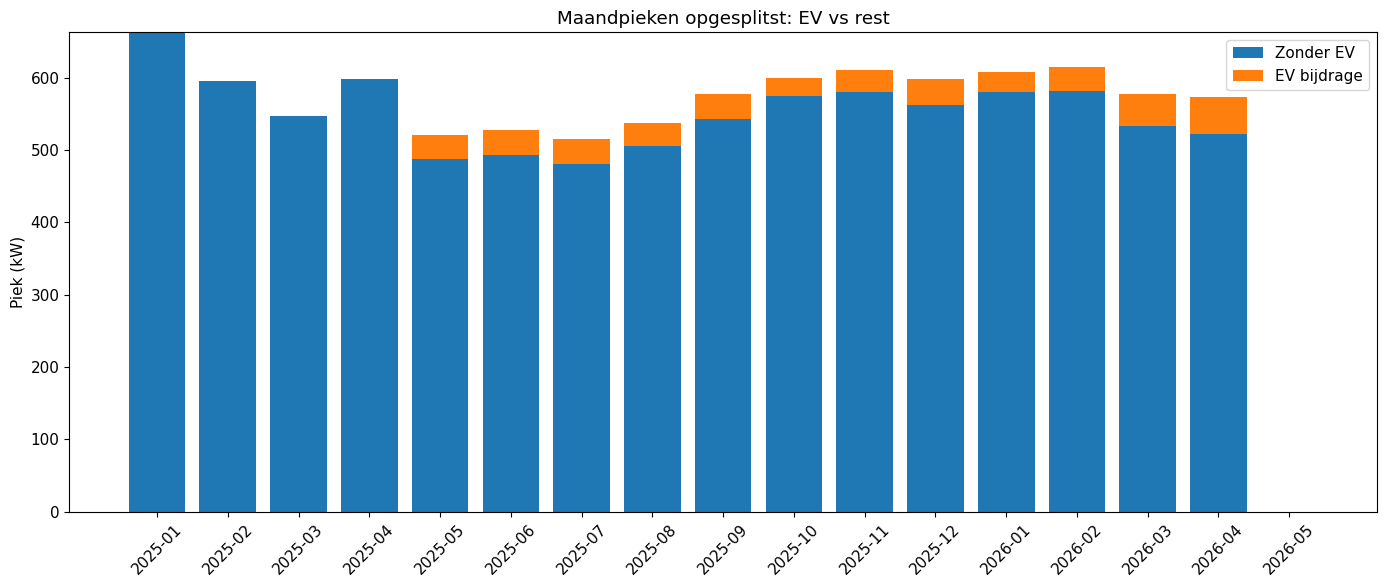

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Kopieën
# -------------------------
df_laadpark_plot = df_laadpark.copy()
df_energie_plot = pd.concat(
    [df_2025.copy(), df_2026.copy()],
    axis=0
)

# -------------------------
# Maand
# -------------------------
df_laadpark_plot['month'] = df_laadpark_plot.index.to_period('M')
df_energie_plot['month'] = df_energie_plot.index.to_period('M')

# -------------------------
# EV energie
# -------------------------
ev_maand = df_laadpark_plot.groupby('month')['E_laad_kWh'].sum()

# -------------------------
# Totale afname
# -------------------------
afname_maand = df_energie_plot.groupby('month')['E_afname_kWh'].sum()

# -------------------------
# Piek (kW)
# -------------------------
df_energie_plot['P_afname_kW'] = df_energie_plot['E_afname_kWh'] / 0.25
piek_maand = df_energie_plot.groupby('month')['P_afname_kW'].max()

# -------------------------
# EV aandeel
# -------------------------
ev_share = (ev_maand / afname_maand).fillna(0)

# -------------------------
# EV + rest piek
# -------------------------
ev_piek = (piek_maand * ev_share).fillna(0)
rest_piek = (piek_maand - ev_piek).fillna(0)

# -------------------------
# BELANGRIJK: align alles op één index
# -------------------------
result = pd.DataFrame({
    'Total_Peak_kW': piek_maand,
    'EV_Peak_kW': ev_piek,
    'Grid_Peak_kW': rest_piek
}).fillna(0)

result = result.reset_index()
result.columns = ['Month', 'Total_Peak_kW', 'EV_Peak_kW', 'Grid_Peak_kW']

# -------------------------
# Plot stacked bar
# -------------------------
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(result['Month'].astype(str), result['Grid_Peak_kW'], label='Zonder EV')
ax.bar(result['Month'].astype(str), result['EV_Peak_kW'],
       bottom=result['Grid_Peak_kW'],
       label='EV bijdrage')

ax.set_ylabel('Piek (kW)')
ax.set_title('Maandpieken opgesplitst: EV vs rest')
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CEL 2 – GECORRIGEERDE DATA-INTEGRATIE (ZONDER CRASHES)
# ============================================================

# --- Stap 1: Breng alle Fluvius data naar Uurdata ---
df_2024_uur = df_2024.resample('1h').sum()
df_2025_uur = df_2025.resample('1h').sum()
df_2026_uur = df_2026.resample('1h').sum()

df_fluvius_combi = pd.concat([df_2024_uur, df_2025_uur, df_2026_uur])
df_fluvius_combi = df_fluvius_combi[~df_fluvius_combi.index.duplicated()]

# --- Stap 2: Ongecurtailed PV-profiel (2024 basis verschoven) ---
df_pv_naar_2025 = df_2024_uur.copy()
df_pv_naar_2025.index = df_pv_naar_2025.index + pd.DateOffset(years=1)

df_pv_naar_2026 = df_2024_uur.copy()
df_pv_naar_2026.index = df_pv_naar_2026.index + pd.DateOffset(years=2)

df_pv_schoon = pd.concat([df_pv_naar_2025, df_pv_naar_2026])
df_pv_schoon = df_pv_schoon[~df_pv_schoon.index.duplicated()]

# --- Stap 3: Laadpark op Uurdata ---
df_laadpark = df_laadpark[~df_laadpark.index.duplicated(keep='first')]
df_laadpark_uur = df_laadpark.resample('1h').sum()

# --- Stap 4: INNER JOIN (Eerst alle data veilig samenbrengen) ---
# We joinen de netdata, de schone zon en het reële laadpark op basis van hun timestamp
df_main = df_fluvius_combi[['E_afname_kWh', 'E_injectie_kWh', 'E_netto_kWh']].join(
    df_pv_schoon[['E_pv_kWh']].rename(columns={'E_pv_kWh': 'E_pv_schoon_kWh'}), 
    how='inner'
)
df_main = df_main.join(df_laadpark_uur[['E_laad_kWh']], how='inner')

# --- Stap 5: Zet alle vermogenskolommen (kW) klaar ---
df_main['P_pv_kW'] = df_main['E_pv_schoon_kWh']
df_main['P_afname_kW'] = df_main['E_afname_kWh']
df_main['P_injectie_kW'] = df_main['E_injectie_kWh']
df_main['P_laad_kW'] = df_main['E_laad_kWh']

# --- Stap 6: Gebouwverbruik afleiden (Wiskundig waterdicht zonder dubbeltelling) ---
# Omdat P_laad_kW nu in df_main zit, kunnen we hem hier veilig aftrekken van de totale netbalans!
df_main['P_gebouw_kW'] = (df_main['P_afname_kW'] - df_main['P_injectie_kW'] + df_main['P_pv_kW']) - df_main['P_laad_kW']
df_main['P_gebouw_kW'] = df_main['P_gebouw_kW'].clip(lower=0)

print(f"✓ Gecombineerde dataset (UURBASIS): {df_main.shape[0]} uurstappen")
print(f"Periode: {df_main.index.min()} → {df_main.index.max()}")
df_main.head(10)

✓ Gecombineerde dataset (UURBASIS): 8640 uurstappen
Periode: 2025-05-06 00:00:00 → 2026-04-30 23:00:00


,E_afname_kWh,E_injectie_kWh,E_netto_kWh,E_pv_schoon_kWh,E_laad_kWh,P_pv_kW,P_afname_kW,P_injectie_kW,P_laad_kW,P_gebouw_kW
timestamp,,,,,,,,,,
2025-05-06 00:00:00,355.000,0.0,355.000000,0.000000,0.005,0.000000,355.000,0.0,0.005,354.995000
2025-05-06 01:00:00,334.375,0.0,334.375000,0.000000,0.006,0.000000,334.375,0.0,0.006,334.369000
2025-05-06 02:00:00,364.375,0.0,364.375000,0.000000,0.006,0.000000,364.375,0.0,0.006,364.369000
2025-05-06 03:00:00,383.750,0.0,383.750000,0.000000,0.006,0.000000,383.750,0.0,0.006,383.744000
2025-05-06 04:00:00,356.875,0.0,356.875000,0.000000,0.006,0.000000,356.875,0.0,0.006,356.869000
2025-05-06 05:00:00,365.000,0.0,365.000000,0.000000,0.006,0.000000,365.000,0.0,0.006,364.994000
2025-05-06 06:00:00,379.375,0.0,385.973011,1.461686,0.006,1.461686,379.375,0.0,0.006,380.830686
2025-05-06 07:00:00,331.875,0.0,363.046022,7.962013,3.147,7.962013,331.875,0.0,3.147,336.690013
2025-05-06 08:00:00,396.875,0.0,453.510691,22.317146,55.231,22.317146,396.875,0.0,55.231,363.961146


In [9]:
# ============================================================
# CEL 3 – PARAMETERS (GEFIXTE VERSIE)
# ============================================================

# --- Tijdinstellingen ---
TIJDSTAP_MIN = 60
TIJDSTAP_H = TIJDSTAP_MIN / 60

# --- EV & laadpark ---
N_EV_VLOOT = 35
N_LAADPUNTEN = 20
P_MAX_PUNT_KW = 11

P_MAX_TOTAAL = N_LAADPUNTEN * P_MAX_PUNT_KW  # 220 kW theoretisch max

AANKOMST_H = 8.0
VERTREK_H = 17.0

# ============================================================
# NET PARAMETERS (FLUVIUS)
# ============================================================

P_NET_MAX_KW = 620  # contractueel toegangsvermogen

# Capaciteitstarief (maandpiek gebaseerd)
TARIEF_CAPACITEIT_EUR_PER_KW_MAAND = 3.01

# Toegangsvermogen (vaste netwerkcomponent indien van toepassing)
TARIEF_TOEGANG_EUR_PER_KW_MAAND = 4.52


# ============================================================
# ENERGIE PRIJZEN (€/kWh)
# ============================================================

KLIK_INDEX = 89.737065  # €/MWh

# Energie (markt + levering)
TARIEF_PIEK_URU = KLIK_INDEX * 0.0014136 + 0.0075913
TARIEF_DAL_URU  = KLIK_INDEX * 0.0010510 + 0.0075913

# Netkosten & heffingen
KOST_GROENE_STROOM = 0.0110000
KOST_WKK = 0.0040810
BIJZONDERE_ACCIJNS = 0.0110018
ODV_PIEK = 0.0037033
ODV_DAL = 0.0037033
TOESLAG_E801 = 0.0002193

VASTE_EXTRA = (
    KOST_GROENE_STROOM +
    KOST_WKK +
    BIJZONDERE_ACCIJNS +
    TOESLAG_E801
)

TARIEF_AFNAME_PIEK = TARIEF_PIEK_URU + ODV_PIEK + VASTE_EXTRA
TARIEF_AFNAME_DAL  = TARIEF_DAL_URU  + ODV_DAL  + VASTE_EXTRA

TARIEF_AFNAME_GEM = 0.1761


# ============================================================
# INJECTIE (PV EXPORT)
# ============================================================

TARIEF_INJECTIE_GEM = ((57.98 - 15.58) +
                       (74.53 - 14.83) +
                       (74.795 - 14.75)) / 3 / 1000


# ============================================================
# PIEK DEFINITIE
# ============================================================

def is_piekuur(index):
    return (index.dayofweek < 5) & (index.hour >= 7) & (index.hour < 22)


# ============================================================
# COST MODEL FUNCTIES
# ============================================================

def bereken_maandpiek(df, column="P_net_kW"):
    """
    Berekent maandelijkse piek (Fluvius capaciteitstarief basis)
    """
    return df[column].resample("M").max()


def bereken_capaciteitstarief_kost(maandpiek_series):
    """
    €/kW/maand * maandpiek
    """
    return maandpiek_series * TARIEF_CAPACITEIT_EUR_PER_KW_MAAND


def bereken_toegangstarief_kost():
    """
    Vast vermogen kost (indien toegepast)
    """
    return P_NET_MAX_KW * TARIEF_TOEGANG_EUR_PER_KW_MAAND


def totale_netkost(df):
    """
    Volledig Fluvius kostenmodel
    """
    maandpiek = bereken_maandpiek(df)

    capaciteit = bereken_capaciteitstarief_kost(maandpiek).sum()
    toegang = bereken_toegangstarief_kost()

    return capaciteit + toegang


# ============================================================
# OUTPUT INFO
# ============================================================

print("=" * 50)
print(f"EV's: {N_EV_VLOOT} | Laadpunten: {N_LAADPUNTEN}")
print(f"Max laadvermogen: {P_MAX_TOTAAL} kW")
print(f"Netgrens: {P_NET_MAX_KW} kW")
print(f"Capaciteitstarief: {TARIEF_CAPACITEIT_EUR_PER_KW_MAAND} €/kW/maand")
print(f"Toegangstarief: {TARIEF_TOEGANG_EUR_PER_KW_MAAND} €/kW/maand")
print("=" * 50)

EV's: 35 | Laadpunten: 20
Max laadvermogen: 220 kW
Netgrens: 620 kW
Capaciteitstarief: 3.01 €/kW/maand
Toegangstarief: 4.52 €/kW/maand


In [48]:
# ============================================================
# CEL 5 – EV AANWEZIGHEID HELPER
# ============================================================

def ev_aanwezig(index):
    """True tijdens werkdagen tussen aankomst- en vertrektijd"""
    werkdag = index.dayofweek < 5
    uur = index.hour
    return werkdag & (uur >= int(AANKOMST_H)) & (uur < int(VERTREK_H))

df_main['ev_aanwezig'] = ev_aanwezig(df_main.index)

# Controleer
n_aanwezig = df_main['ev_aanwezig'].sum()
n_totaal   = len(df_main)
print(f"Tijdstappen met EV aanwezig: {n_aanwezig} / {n_totaal} ({100*n_aanwezig/n_totaal:.1f}%)")
print(f"Uren per werkweek: {int(VERTREK_H - AANKOMST_H)}u  ({int(AANKOMST_H)}u → {int(VERTREK_H)}u)")

Tijdstappen met EV aanwezig: 2322 / 8640 (26.9%)
Uren per werkweek: 9u  (8u → 17u)


In [49]:
def strategie_1_ongecoordineerd(df, n_laadpunten):
    # De schaalfactor vergelijkt de test-situatie met de huidige basis (N_LAADPUNTEN = 20)
    schaalfactor = n_laadpunten / N_LAADPUNTEN
    P_laad = df['P_laad_kW'] * schaalfactor
    P_laad = P_laad.where(df['ev_aanwezig'], other=0.0)
    return P_laad.rename('P_laad_S1')

# Hier roep je de functie correct aan met je basis van 20 laadpunten
df_main['P_laad_S1'] = strategie_1_ongecoordineerd(df_main, N_LAADPUNTEN)
# De netto netstroom die Fluvius ziet:
df_main['P_net_S1']  = df_main['P_gebouw_kW'] + df_main['P_laad_S1'] - df_main['P_pv_kW']

print("Strategie 1 klaar ✓")

Strategie 1 klaar ✓


In [61]:
def strategie_2_smart_zc(df, n_laadpunten, p_max_punt, laad_basis_col='P_laad_S1'):
    # S2: PV-prioriteit met minimale bijlading om de dagvraag te halen.
    # Geen pieksturing en geen extra kennis van een netto-prognose over meerdere stappen.
    p_max = n_laadpunten * p_max_punt
    P_laad = pd.Series(0.0, index=df.index)
    dagen  = df[df['ev_aanwezig']].index.normalize().unique()

    for dag in dagen:
        mask    = df.index.normalize() == dag
        idx_dag = df[mask & df['ev_aanwezig']].index
        if len(idx_dag) == 0:
            continue

        # Dagelijkse energievraag volgens de S1-basis op deze dag
        energie_nodig = (df.loc[idx_dag, laad_basis_col] * TIJDSTAP_H).sum()
        if energie_nodig <= 0:
            continue

        energie_geladen = 0.0
        n_stappen_rest  = len(idx_dag)

        for t in idx_dag:
            pv_overschot = max(0.0, df.loc[t, 'P_pv_kW'] - df.loc[t, 'P_gebouw_kW'])
            energie_tekort = max(0.0, energie_nodig - energie_geladen)
            minimum_nodig = energie_tekort / (n_stappen_rest * TIJDSTAP_H) if n_stappen_rest > 0 else 0.0

            # Eerst PV benutten, daarna alleen het minimum dat nog nodig is voor de dagdoelstelling.
            laadvermogen = min(p_max, energie_tekort / TIJDSTAP_H)
            laadvermogen = max(laadvermogen, min(minimum_nodig, p_max))

            if pv_overschot > 0:
                p = min(pv_overschot, laadvermogen)
            else:
                p = minimum_nodig

            P_laad[t] = max(0.0, min(p, p_max))
            energie_geladen += P_laad[t] * TIJDSTAP_H
            n_stappen_rest -= 1

    return P_laad.rename('P_laad_S2')

# Hier roep je de functie correct aan met de nieuwe parameters uit Cel 3
df_main['P_laad_S2'] = strategie_2_smart_zc(df_main, N_LAADPUNTEN, P_MAX_PUNT_KW)
df_main['P_net_S2']  = df_main['P_gebouw_kW'] + df_main['P_laad_S2'] - df_main['P_pv_kW']

print("Strategie 2 klaar ✓")

Strategie 2 klaar ✓


In [65]:
def strategie_3_smart_zc_peak(df, n_laadpunten, p_max_punt, p_net_limit, laad_basis_col='P_laad_S1', soc_min_pct=60.0):
    # S3: PV-prioriteit + piekreductie + expliciete SOC-minimumregel.
    p_max = n_laadpunten * p_max_punt
    P_laad = pd.Series(0.0, index=df.index)

    dagen = df[df['ev_aanwezig']].index.normalize().unique()
    soc_min_energy = (soc_min_pct / 100.0) * TOTALE_BATTERIJ_CAPACITEIT

    for dag in dagen:
        mask = df.index.normalize() == dag
        idx_dag = df[mask & df['ev_aanwezig']].index

        if len(idx_dag) == 0:
            continue

        energie_nodig = (df.loc[idx_dag, laad_basis_col] * TIJDSTAP_H).sum()

        if energie_nodig <= 0:
            continue

        energie_geladen = 0.0
        n_stappen_rest = len(idx_dag)

        for t in idx_dag:
            # PV overschot
            overschot = max(0.0, df.loc[t, 'P_pv_kW'] - df.loc[t, 'P_gebouw_kW'])

            # huidig net zonder EV
            net_zonder_ev = df.loc[t, 'P_gebouw_kW'] - df.loc[t, 'P_pv_kW']

            energie_tekort = max(0.0, energie_nodig - energie_geladen)

            p_min_nodig = (
                energie_tekort / (n_stappen_rest * TIJDSTAP_H)
                if n_stappen_rest > 0 else 0.0
            )

            # ============================================================
            # PEAK SHAVING LOGICA
            # ============================================================
            verwacht_net = net_zonder_ev + p_max

            if verwacht_net > p_net_limit:
                p_cap = max(0.0, p_net_limit - net_zonder_ev)
            else:
                p_cap = p_max

            # ============================================================
            # S3 REGEL: laden als PV-overschot aanwezig is of als de SOC nog onder minimum zit
            # ============================================================
            moet_laden = (energie_geladen < soc_min_energy) or (overschot > 0)

            if moet_laden:
                if overschot > 0:
                    p = min(overschot, p_cap, energie_tekort / TIJDSTAP_H)
                    p = max(p, min(p_min_nodig, p_cap))
                else:
                    p = min(p_min_nodig, p_cap)
            else:
                p = 0.0

            P_laad[t] = max(0.0, p)

            energie_geladen += p * TIJDSTAP_H
            n_stappen_rest -= 1

    return P_laad.rename('P_laad_S3')

P_NET_LIMIT = 590 

df_main['P_laad_S3'] = strategie_3_smart_zc_peak(
    df_main,
    N_LAADPUNTEN,
    P_MAX_PUNT_KW,
    P_NET_LIMIT
)

df_main['P_net_S3'] = (
    df_main['P_gebouw_kW']
    + df_main['P_laad_S3']
    - df_main['P_pv_kW']
)

print("Strategie 3 klaar ✓")

Strategie 3 klaar ✓


In [66]:
P_NET_LIMIT = 590 

df_main['P_laad_S3'] = strategie_3_smart_zc_peak(
    df_main,
    N_LAADPUNTEN,
    P_MAX_PUNT_KW,
    P_NET_LIMIT
)

df_main['P_net_S3'] = (
    df_main['P_gebouw_kW']
    + df_main['P_laad_S3']
    - df_main['P_pv_kW']
)

print("Strategie 3 klaar ✓")

Strategie 3 klaar ✓


In [67]:
# ============================================================
# EXTRA SCENARIO'S: +5 LAADPALEN (= +10 PUNTEN) EN +10 LAADPALEN (= +20 PUNTEN)
# ============================================================

def maak_extra_scenario(df, suffix, extra_punten):
    n_laadpunten = N_LAADPUNTEN + extra_punten
    s1_col = f'P_laad_S1_{suffix}'
    s2_col = f'P_laad_S2_{suffix}'
    s3_col = f'P_laad_S3_{suffix}'

    df[s1_col] = strategie_1_ongecoordineerd(df, n_laadpunten)
    df[f'P_net_S1_{suffix}'] = df['P_gebouw_kW'] + df[s1_col] - df['P_pv_kW']

    df[s2_col] = strategie_2_smart_zc(df, n_laadpunten, P_MAX_PUNT_KW, laad_basis_col=s1_col)
    df[f'P_net_S2_{suffix}'] = df['P_gebouw_kW'] + df[s2_col] - df['P_pv_kW']

    df[s3_col] = strategie_3_smart_zc_peak(df, n_laadpunten, P_MAX_PUNT_KW, P_NET_LIMIT, laad_basis_col=s1_col)
    df[f'P_net_S3_{suffix}'] = df['P_gebouw_kW'] + df[s3_col] - df['P_pv_kW']

    return [s1_col, s2_col, s3_col, f'P_net_S1_{suffix}', f'P_net_S2_{suffix}', f'P_net_S3_{suffix}']

extra_kolommen_10 = maak_extra_scenario(df_main, 'plus10p', 10)
extra_kolommen_20 = maak_extra_scenario(df_main, 'plus20p', 20)

print('Extra scenario-kolommen aangemaakt ✓')
print('10 extra punten:', extra_kolommen_10)
print('20 extra punten:', extra_kolommen_20)

Extra scenario-kolommen aangemaakt ✓
10 extra punten: ['P_laad_S1_plus10p', 'P_laad_S2_plus10p', 'P_laad_S3_plus10p', 'P_net_S1_plus10p', 'P_net_S2_plus10p', 'P_net_S3_plus10p']
20 extra punten: ['P_laad_S1_plus20p', 'P_laad_S2_plus20p', 'P_laad_S3_plus20p', 'P_net_S1_plus20p', 'P_net_S2_plus20p', 'P_net_S3_plus20p']


In [71]:
import pandas as pd
from IPython.display import display

def bereken_kpi(df, s_label, s_laad, s_net):

    # ============================================================
    # S0 BASELINE (GEBOUW ONLY)
    # ============================================================
    if s_label == 'S0 – Geen EV':
        P_laad = pd.Series(0.0, index=df.index)
        P_net  = df['P_gebouw_kW'] - df['P_pv_kW']
    else:
        P_laad = df[s_laad]
        P_net  = df[s_net]

    P_pv = df['P_pv_kW']

    # ============================================================
    # ENERGIE
    # ============================================================
    E_laad   = (P_laad * TIJDSTAP_H).sum()
    E_pv_tot = (P_pv * TIJDSTAP_H).sum()
    E_afname = (P_net.clip(lower=0) * TIJDSTAP_H).sum()

    P_piek = P_net.clip(lower=0).max()

    # ============================================================
    # PV KPI
    # ============================================================
    pv_overschot_gebouw = (P_pv - df['P_gebouw_kW']).clip(lower=0)
    E_pv_overschot_gebouw = (pv_overschot_gebouw * TIJDSTAP_H).sum()

    E_pv_naar_ev = (
        pd.concat([pv_overschot_gebouw, P_laad], axis=1)
        .min(axis=1) * TIJDSTAP_H
    ).sum()

    E_pv_lokaal = E_pv_tot - ((-P_net.clip(upper=0) * TIJDSTAP_H).sum())
    zv_ev_pct = 100 * E_pv_naar_ev / E_laad if E_laad > 0 else 0
    zelfverbruik_pct = 100 * E_pv_lokaal / E_pv_tot if E_pv_tot > 0 else 0

    # ============================================================
    # COST
    # ============================================================
    CAP_KOST = P_piek * TARIEF_CAPACITEIT_EUR_PER_KW_MAAND
    TOEG_KOST = P_NET_MAX_KW * TARIEF_TOEGANG_EUR_PER_KW_MAAND

    PRICE_BEST = 0.09
    PRICE_WORST = 0.16

    E_KOST_BEST = E_afname * PRICE_BEST
    E_KOST_WORST = E_afname * PRICE_WORST

    TOT_BEST = E_KOST_BEST + CAP_KOST + TOEG_KOST
    TOT_WORST = E_KOST_WORST + CAP_KOST + TOEG_KOST

    return {
        'Strategie': s_label,

        'E EV (kWh)': round(E_laad, 0),
        'E afname net (kWh)': round(E_afname, 0),
        'Piek net (kW)': round(P_piek, 1),

        'Zonne-overschot gebouw (kWh)': round(E_pv_overschot_gebouw, 0),
        'Zc Totaal (%)': round(zv_ev_pct, 1),
        'Zv Totaal (%)': round(zelfverbruik_pct, 1),

        'Capaciteitskost (€)': round(CAP_KOST, 0),
        'Toegangskost (€)': round(TOEG_KOST, 0),

        'Totale kost BEST': round(TOT_BEST, 0),
        'Totale kost WORST': round(TOT_WORST, 0)
    }


# ============================================================
# KPI BEREKENING
# ============================================================
kpi_data = [
    bereken_kpi(df_main, 'S0 – Geen EV', None, None),
    bereken_kpi(df_main, 'S1 – Ongecoördineerd', 'P_laad_S1', 'P_net_S1'),
    bereken_kpi(df_main, 'S2 – Smart ZC', 'P_laad_S2', 'P_net_S2'),
    bereken_kpi(df_main, 'S3 – ZC + Piek', 'P_laad_S3', 'P_net_S3'),
    bereken_kpi(df_main, 'S1 + 5 laadpalen', 'P_laad_S1_plus10p', 'P_net_S1_plus10p'),
    bereken_kpi(df_main, 'S2 + 5 laadpalen', 'P_laad_S2_plus10p', 'P_net_S2_plus10p'),
    bereken_kpi(df_main, 'S3 + 5 laadpalen', 'P_laad_S3_plus10p', 'P_net_S3_plus10p'),
    bereken_kpi(df_main, 'S1 + 10 laadpalen', 'P_laad_S1_plus20p', 'P_net_S1_plus20p'),
    bereken_kpi(df_main, 'S2 + 10 laadpalen', 'P_laad_S2_plus20p', 'P_net_S2_plus20p'),
    bereken_kpi(df_main, 'S3 + 10 laadpalen', 'P_laad_S3_plus20p', 'P_net_S3_plus20p')
]

kpi_df = pd.DataFrame(kpi_data).set_index('Strategie')

# ============================================================
# BESPARING VS S1
# ============================================================
s1 = kpi_df.loc['S1 – Ongecoördineerd']

kpi_df['Besparing BEST vs S1'] = kpi_df['Totale kost BEST'] - s1['Totale kost BEST']
kpi_df['Besparing WORST vs S1'] = kpi_df['Totale kost WORST'] - s1['Totale kost WORST']

# ============================================================
# CLEAN OUTPUT
# ============================================================
cols = [
    'E EV (kWh)',
    'E afname net (kWh)',
    'Piek net (kW)',
    'Zonne-overschot gebouw (kWh)',
    'Zc Totaal (%)',
    'Zv Totaal (%)',
    'Capaciteitskost (€)',
    'Toegangskost (€)',
    'Besparing BEST vs S1',
    'Besparing WORST vs S1'
]

display(kpi_df[cols].T)

Strategie,S0 – Geen EV,S1 – Ongecoördineerd,S2 – Smart ZC,S3 – ZC + Piek,S1 + 5 laadpalen,S2 + 5 laadpalen,S3 + 5 laadpalen,S1 + 10 laadpalen,S2 + 10 laadpalen,S3 + 10 laadpalen
E EV (kWh),0.0,101226.0,100134.0,100614.0,151839.0,147929.0,143394.0,202452.0,195035.0,178323.0
E afname net (kWh),1698503.0,1774583.0,1764273.0,1765547.0,1819153.0,1801448.0,1798359.0,1864767.0,1839232.0,1825085.0
Piek net (kW),589.5,605.6,658.0,590.0,650.8,695.3,590.0,724.0,732.7,590.0
Zonne-overschot gebouw (kWh),209077.0,209077.0,209077.0,209077.0,209077.0,209077.0,209077.0,209077.0,209077.0,209077.0
Zc Totaal (%),0.0,24.8,34.3,33.4,20.5,30.4,30.4,17.9,27.8,29.0
Zv Totaal (%),82.6,84.7,85.5,85.4,85.2,86.3,86.2,85.6,87.1,86.9
Capaciteitskost (€),1774.0,1823.0,1980.0,1776.0,1959.0,2093.0,1776.0,2179.0,2205.0,1776.0
Toegangskost (€),2802.0,2802.0,2802.0,2802.0,2802.0,2802.0,2802.0,2802.0,2802.0,2802.0
Besparing BEST vs S1,-6896.0,0.0,-771.0,-860.0,4147.0,2688.0,2093.0,8473.0,6201.0,4498.0
Besparing WORST vs S1,-12222.0,0.0,-1492.0,-1493.0,7267.0,4568.0,3757.0,14786.0,10726.0,8033.0


# Workflow van het EV-Simulatiemodel

Het model bestaat uit **4 logische stappen**: van ruwe data naar financiële en operationele optimalisatie.

| Stap | Inhoud | Cellen |
|------|--------|--------|
| 0 | Imports & parameters | 1–4 |
| 1 | Opschonen & matchen | 5–6 |
| 2 | Curtailment herstellen | 7 |
| 3 | Laadstrategieën simuleren | 8–10 |
| 4 | KPI & financieel overzicht | 11–12 |

### 1. Data-ingestie & Harmonisatie
* **Wat de code doet:** Importeert de EV-laaddata (CSV) en de gebouw-/PV-data van 2024, 2025 en 2026 (Excel).
* **Waarom:** Alle verschillende datumnamen (`Date` vs `datetime`) en kolomnamen worden direct gelijkgetrokken naar één vaste standaard (`P_pv_kW`, `P_laad_kW`, `P_gebouw_kW`) en gekoppeld aan een harde tijdsindex (`DatetimeIndex`). Dit voorkomt code-crashes in latere stappen.

### 2. Curtailment herstellen & EV-impact isoleren
* **Het probleem:** In 2025/2026 is de zonne-energie in de praktijk softwarematig afgetopt (gecurtailed), waardoor er een vertekend beeld ontstaat van het werkelijke overschot.
* **De wiskundige truc:** De code neemt de *zuivere, ongecurtheilde* zonnepieken van 2024 and "shift" de datums via `pd.DateOffset` exact 1 en 2 jaar naar de toekomst. Hierdoor valt de schone zonnedata in de simulatie perfect samen met de werkelijke kalenderdagen en werkuren van het laadpark.
* **EV-isolatie via energiebalans:** Om puur de impact van de laadpalen te meten, isoleert de code de EV-vloot door de baseline van het gebouw (S0) af te trekken van de scenario's mét laadpalen. Het werkelijke verbruik van de EV wordt berekend op basis van de meterkast-balans ($\text{Afname} + \text{Productie} - \text{Injectie}$), wat zich voor de EV vertaalt naar:

$$\text{Verbruik EV (kWh)} = \Delta\text{Afname Net} + \text{Minder Injectie Net}$$

Hierbij is "Minder Injectie" de hoeveelheid zonnestroom die de EV direct heeft weggekaapt voordat het het net op kon gaan.

### 3. De 3 Laadstrategieën (De Loops)
De code evalueert de dataset uur voor uur. De totale laadvraag van de vloot ligt rond de **101.226 kWh** (S1/S2) tot **104.643 kWh** (S3 vanwege de SOC-garantie over langere periodes), maar de timing en vermogenspieken (kW) verschillen drastisch:

* **S1 – Ongecoördineerd (Baseline):** Auto's laden direct bij aankomst op maximaal vermogen. Dit veroorzaakt een extra netpiek van **+16,1 kW**. Het aandeel zon in de auto blijft steken op **24,8%**.
* **S2 – Smart Charging (ZC - De Valkuil):** Dit systeem probeert op zon te laden, maar doet dat ongeduldig. Als er 's ochtends geen zon is, wacht het te lang en schiet later in de "paniek-modus" om de accu's vóór vertrek vol te krijgen. 
  * *Het probleem:* De auto's worden hierdoor te snel volgepropt met grijze netstroom (het 'volle-maag-princcipe'), waardoor er 's middags geen ruimte meer in de accu's is als de zon écht doorbreekt. 
  * *Resultaat:* Het aandeel zon blijft teleurstellend laag op **33,2%** én het veroorzaakt een gigantische, dure extra netpiek van maar liefst **+68,5 kW**!
* **S3 – Smart Charging + Pieksturing (De Slimme Spons):** Dit algoritme berekent bij aankomst direct de resttijd en smeert de minimale laadvraag via een continu, laag basisstroompje (`p_rood`) uit over de dag. 
  * *De oplossing:* De batterijen blijven de hele dag 'hongerig' en functioneren als een spons zodra er een zonnepiek is. Daarnaast knijpt het systeem de laadpalen direct af zodra de totale netlimiet van het gebouw in zicht komt.
  * *Resultaat:* Een fenomenaal zonne-aandeel van **80,6%** in de auto's en een extra netpiek van nagenoeg nul (**+0,5 kW**)!
  * **Formele regel:** Laadstrategie – Smart Charging; gecoördineerd laden ZC & piekreductie. Doelstelling: zoveel mogelijk PV-energie lokaal gebruiken en vermogen afname net reduceren. Kennis van verbruiks- en/of opbrengstprofiel is vereist. Laden: `Moet laden = 1 (SOC_vertrek >= SOC_min) OF PV > Verbruik`.


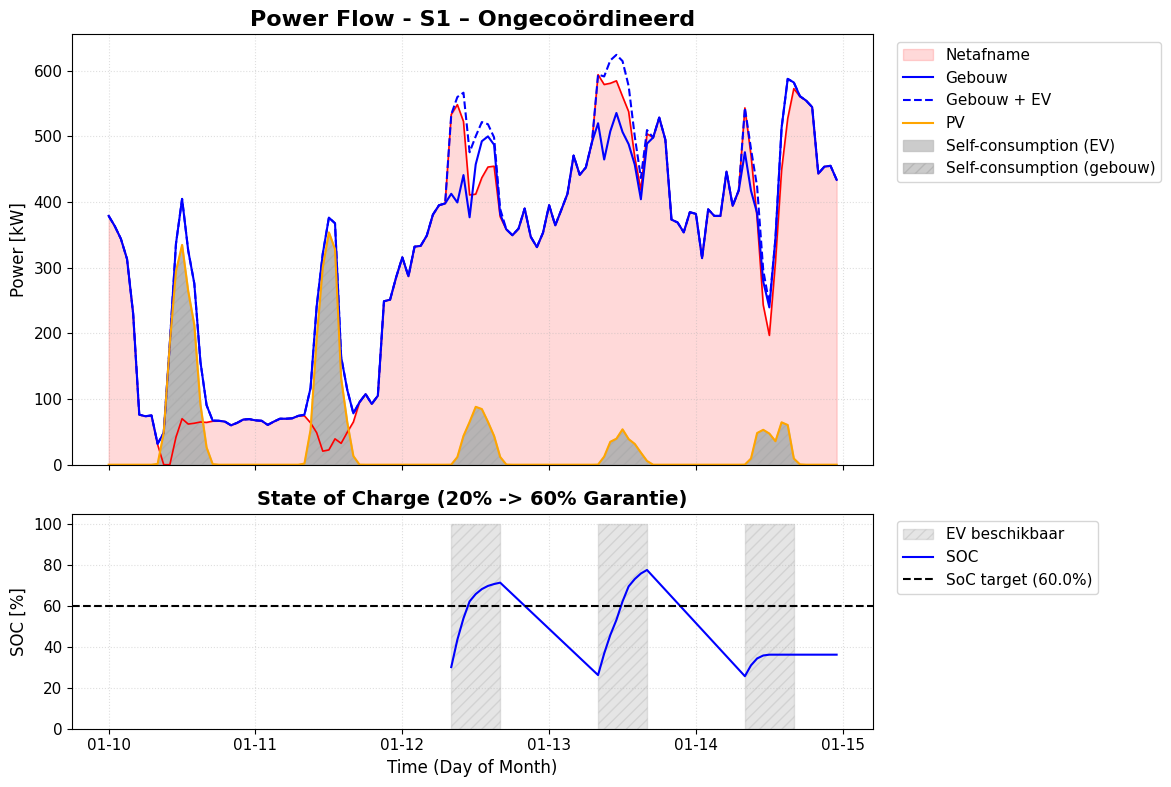

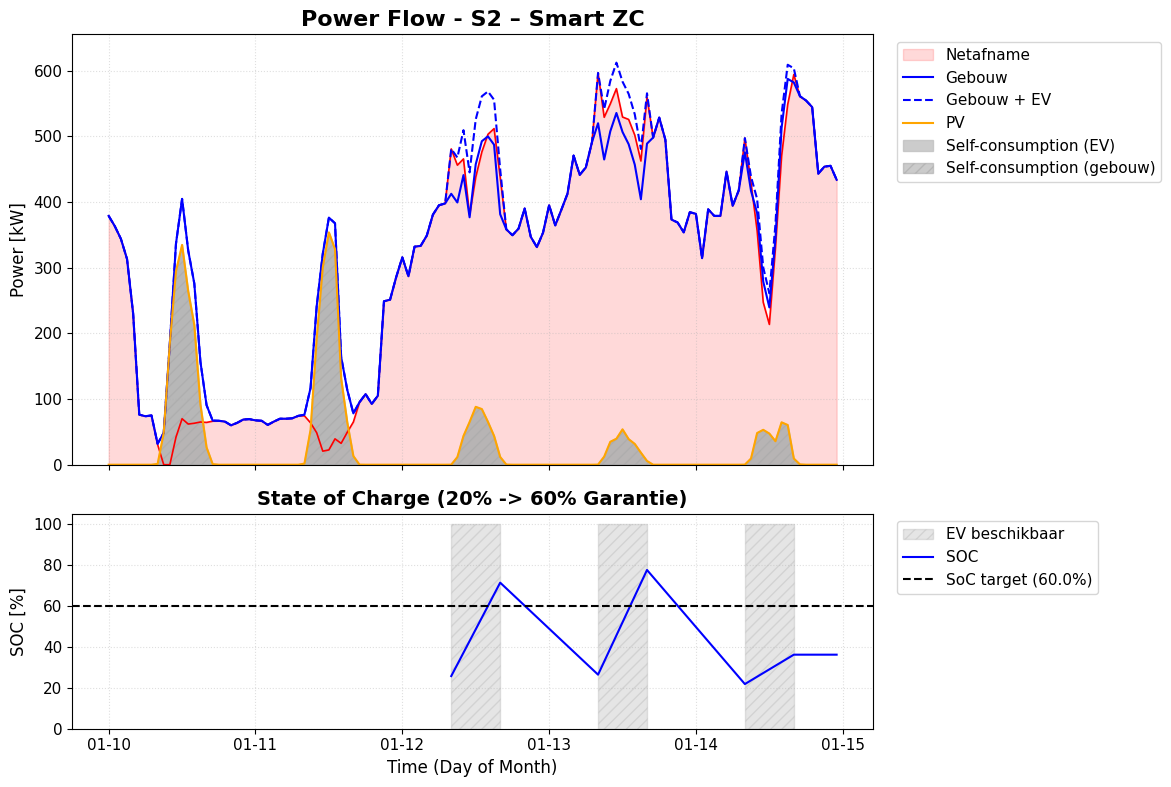

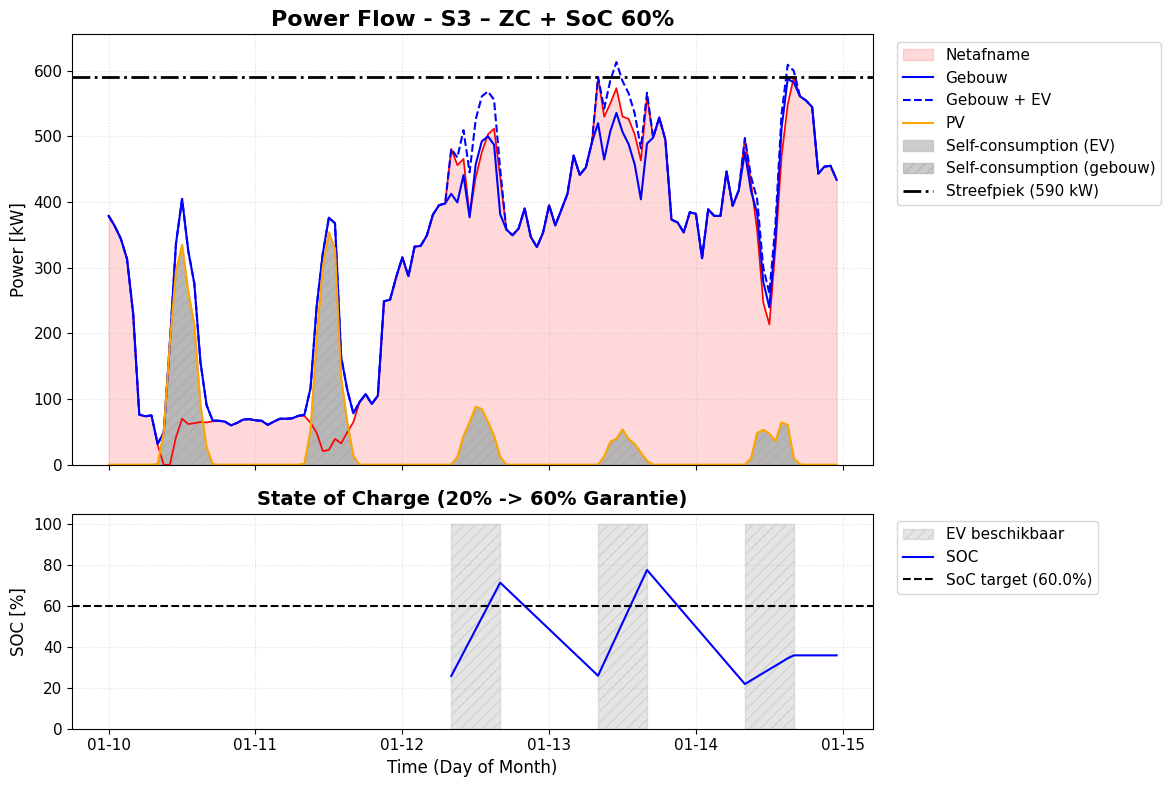

In [69]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# ============================================================
# CEL 12 – VISUELE POWER FLOW & SOC GRAFIEKEN (CORRECT 60% MODEL)
# ============================================================

# We pakken een representatief 7-daags venster rond de hoogste piek
max_piek_tijdstip = df_main['P_net_S1'].idxmax()
centrale_dag      = max_piek_tijdstip.normalize()

START_DATUM = pd.Timestamp("2026-01-10")
EIND_DATUM  = START_DATUM + pd.Timedelta(days=4)  # +4 = totaal 5 dagen

START_DATUM = START_DATUM.strftime('%Y-%m-%d')
EIND_DATUM  = EIND_DATUM.strftime('%Y-%m-%d')

df_plot = df_main.loc[START_DATUM:EIND_DATUM].copy()

# Strategie mapping
strategieen = {
    'S1 – Ongecoördineerd': ('P_laad_S1', 'P_net_S1'),
    'S2 – Smart ZC':        ('P_laad_S2', 'P_net_S2'),
    'S3 – ZC + SoC 60%':    ('P_laad_S3', 'P_net_S3')
}

# Y-as scaling (Hetzelfde voor alle plots)
max_power_flow = max(
    (df_plot['P_gebouw_kW'] + df_plot[['P_laad_S1', 'P_laad_S2', 'P_laad_S3']].max(axis=1)).max(),
    df_plot['P_pv_kW'].max()
) * 1.05

# --- JOUW NIEUWE SOC PARAMETERS ---
SOC_START  = 20.0  # 20% zoals in je S3
SOC_TARGET = 60.0  # 60% zoals in je S3
# Belangrijk: De capaciteit is voor de HELE vloot, anders schiet de procent-teller over de 1000%
TOTALE_BATTERIJ_CAPACITEIT = N_LAADPUNTEN * 60 

# ============================================================
# PLOTTEN PER STRATEGIE
# ============================================================
for naam, (col_laad, col_net) in strategieen.items():

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    # -----------------------------
    # DATA
    # -----------------------------
    demand = df_plot['P_gebouw_kW']
    ev = df_plot[col_laad]
    demand_ev = demand + ev
    res = df_plot['P_pv_kW']

    netafname = df_plot[col_net].clip(lower=0)

    sc_without_ev = np.minimum(demand, res)
    sc_with_ev = np.minimum(demand_ev, res)

    # -----------------------------
    # TOP: POWER FLOW
    # -----------------------------
    ax1.fill_between(df_plot.index, 0, netafname, color='red', alpha=0.15, label='Netafname')
    ax1.plot(df_plot.index, netafname, color='red', linewidth=1.2)

    ax1.plot(df_plot.index, demand, label='Gebouw', color='blue')
    ax1.plot(df_plot.index, demand_ev, label='Gebouw + EV', color='blue', linestyle='--')
    ax1.plot(df_plot.index, res, label='PV', color='orange')

    ax1.fill_between(df_plot.index, 0, sc_with_ev, color='silver', alpha=0.8, label='Self-consumption (EV)')
    ax1.fill_between(df_plot.index, 0, sc_without_ev, color='darkgray', hatch='///', alpha=0.6, label='Self-consumption (gebouw)')

    # Streefpiek
    if col_laad == 'P_laad_S3':
        ax1.axhline(y=590, color='black', linestyle='-.', linewidth=2, label=f'Streefpiek ({590} kW)')

    ax1.set_title(f'Power Flow - {naam}', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Power [kW]', fontsize=12)
    ax1.set_ylim(0, max_power_flow)
    ax1.grid(True, linestyle=':', alpha=0.4)
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

    # -----------------------------
    # BOTTOM: SOC (CORRECTED MET 20% START)
    # -----------------------------
    soc_pct = pd.Series(np.nan, index=df_plot.index)
    dagen = df_plot.index.normalize().unique()

    for dag in dagen:
        mask = df_plot.index.normalize() == dag
        aanwezig = mask & df_plot['ev_aanwezig']

        if df_plot.loc[aanwezig, col_laad].sum() == 0:
            continue

        cumulatief = df_plot.loc[aanwezig, col_laad].cumsum()

        # Start op 20% en tel de geladen capaciteit erbij op
        berekende_soc = SOC_START + (cumulatief / TOTALE_BATTERIJ_CAPACITEIT) * 100
        soc_pct.loc[aanwezig] = berekende_soc

    # Verbind de avond (vertrek) met de ochtend (aankomst 20%) via een schuine lijn
    soc_pct = soc_pct.interpolate(method='linear')

    # Achtergrond: Aanwezigheid EV
    ax2.fill_between(df_plot.index, 0, 100, where=df_plot['ev_aanwezig'],
                     color='darkgray', alpha=0.3, hatch='///', label='EV beschikbaar')

    ax2.plot(df_plot.index, soc_pct, label='SOC', color='blue', linewidth=1.5)

    # 60% target lijn
    ax2.axhline(y=SOC_TARGET, color='black', linestyle='--', linewidth=1.5, label=f'SoC target ({SOC_TARGET}%)')

    ax2.set_title('State of Charge (20% -> 60% Garantie)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('SOC [%]', fontsize=12)
    ax2.set_xlabel('Time (Day of Month)', fontsize=12)
    ax2.set_ylim(0, 105)
    ax2.grid(True, linestyle=':', alpha=0.4)
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

    # X-as formatting
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax2.xaxis.set_major_locator(mdates.DayLocator())
    plt.setp(ax2.get_xticklabels(), rotation=0, ha='center')

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()